# Regression Models
To predict corn returns at time t+1

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.stats.outliers_influence import variance_inflation_factor

from xgboost import XGBRegressor

from sklearn.model_selection import TimeSeriesSplit
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import Lasso, Ridge, ElasticNet, LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

df = pd.read_csv("enriched_corn_data.csv")[1:]
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)
df

,corn_close,corn_volume,corn_ret,corn_volume_roll_z,corn_rv_5d,corn_rv_20d,month,atr_14,sma_spread,"macd_(12,26,9)",...,prod_w_prcp,prod_w_rhum,prod_w_wspd,temp_prcp_interaction,corn_rv_5d_lag1,corn_rv_5d_lag2,rsi_14_lag1,rsi_14_lag2,d(yc_10_2)_lag1,d(yc_10_2)_lag2
Date,,,,,,,,,,,,,,,,,,,,,
2000-10-03,195.25,3.0,0.016927,-0.484432,0.018853,0.055290,10.0,1.857143,0.031072,2.314839,...,1.036692,51.591682,11.692289,14.212231,0.021779,NaN,68.674699,NaN,NaN,NaN
2000-10-04,199.50,3.0,0.021767,-0.520727,0.028676,0.059405,10.0,1.964286,0.036285,2.608881,...,5.597392,60.499126,13.658984,60.246159,0.018853,0.021779,70.786517,68.674699,2.000000e-02,NaN
2000-10-05,200.50,3.0,0.005013,-0.520727,0.029111,0.057702,10.0,2.535714,0.043004,2.943438,...,12.300664,67.352749,12.139667,88.277538,0.028676,0.018853,86.956522,70.786517,0.000000e+00,2.000000e-02
2000-10-06,199.50,3.0,-0.004988,-0.520727,0.028466,0.050595,10.0,2.785714,0.045840,3.263189,...,0.000000,47.716438,13.418457,0.000000,0.029111,0.028676,93.333333,86.956522,-2.000000e-02,0.000000e+00
2000-10-09,199.50,3.0,0.000000,-0.520727,0.028466,0.050425,10.0,3.392857,0.048856,3.549460,...,0.000000,41.838123,7.896974,0.000000,0.028466,0.029111,87.804878,93.333333,-1.000000e-02,-2.000000e-02
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-04-02,452.25,0.0,-0.004403,-2.807366,0.019868,0.050363,4.0,10.178571,0.001921,6.818618,...,0.490944,51.256284,10.833227,2.614031,0.019382,0.020559,55.309735,61.842105,1.000000e-02,-2.000000e-02
2026-04-06,454.00,126749.0,0.003870,0.403609,0.017178,0.048951,4.0,9.625000,-0.002358,6.369381,...,0.000000,30.310008,9.399977,0.000000,0.019868,0.019382,49.769585,55.309735,-4.440892e-16,1.000000e-02
2026-04-07,449.00,172653.0,-0.011013,0.429768,0.015276,0.045451,4.0,9.410714,-0.006572,5.821673,...,0.000000,17.532417,5.801164,0.000000,0.017178,0.019868,50.000000,49.769585,-2.000000e-02,-4.440892e-16


We tune all models using 10-split time-series cross-validation on the training sample to preserve chronological ordering and avoid look-ahead bias, then evaluate the selected models on a final holdout test period. The final holdout test period gives us an unbiased approximation of test error which cross-validation cannot since we tune hyperparameters using CV so we cherry-pick models with the lowest CV error and hence it is biased downwards.

In [50]:
feature_cols = [
    'corn_ret', 'corn_volume_roll_z','corn_rv_5d', 'corn_rv_20d', 
    'month',
    'atr_14', 'sma_spread', 'macd_(12,26,9)', 'rsi_14',
    'oil_close_roll_z', 'soy_close_roll_z', 'corn_soy_ratio', 'corn_oil_ratio',
    'yc_10_2', 'yc_2_3m', 'yc_curvature', 
    'd(yc_10_2)', 'd(yc_2_3m)', 'd(yc_curvature)', 'd(T10_yield)', 'd(T2_yield)',
    'prod_w_temp', 'prod_w_tmin', 'prod_w_tmax', 'prod_w_prcp', 'prod_w_rhum', 'prod_w_wspd'
]
mlr_features = feature_cols + ['temp_prcp_interaction', 'corn_rv_5d_lag1', 'corn_rv_5d_lag2', 'rsi_14_lag1', 'rsi_14_lag2', 'd(yc_10_2)_lag1', 'd(yc_10_2)_lag2']
response_col = 'corn_ret_t+1'
model_df = df[mlr_features + [response_col]].copy()
if "date" in df.columns:
    model_df = df[["date"] + mlr_features + [response_col]].copy()
    model_df["date"] = pd.to_datetime(model_df["date"])
    model_df = model_df.sort_values("date")
else:
    model_df = model_df.sort_index()
model_df = model_df.dropna(subset=[response_col])

# Final clean feature and response data
X = model_df[mlr_features]
y = model_df[response_col]

# 80-20 Train-Test split for unbiased holdout test period
split_idx = int(len(model_df) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

# Month is a categorical variable
categorical_cols = ["month"]
numeric_cols = [c for c in feature_cols if c not in categorical_cols]

# Setting up feature preprocessing pipelines
preprocessor_scaled = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),  # to fill NaN values
        ("scaler", StandardScaler())        # Scaling needed for Lasso, etc. except for Regression Trees & Random Forests
    ]), numeric_cols),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),   # to fill NaN values
        ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore"))
    ]), categorical_cols)
])
preprocessor_noscale = ColumnTransformer([
    ("num", SimpleImputer(strategy="median"), numeric_cols),    # Scaling not needed here
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore"))
    ]), categorical_cols)
])

We perform a special type of CV called Time-Series CV which does not shuffle the folds unlike standard K-fold CV to preserve the chronological order of the data and to avoid look-ahead bias caused by future folds being used in the shuffled training set.

In [51]:
# 10-fold Time-Series Cross Validation
tscv = TimeSeriesSplit(n_splits=10)

# Helper to calculate RMSE for CV
def cv_rmse(model, X, y, cv):
    rmses = []
    for train_idx, val_idx in cv.split(X):
        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

        model.fit(X_tr, y_tr)
        preds = model.predict(X_val)
        rmse = np.sqrt(mean_squared_error(y_val, preds))
        rmses.append(rmse)
    return np.mean(rmses)

# Helper to calculate RMSE, MAE, and R^2 for final holdout test period
def evaluate_holdout(name, model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    return {
        "model": name,
        "test_rmse": np.sqrt(mean_squared_error(y_test, preds)),
        "test_mae": mean_absolute_error(y_test, preds),
        "test_r2": r2_score(y_test, preds)
    }

## Linear Regression

In [52]:
# MLR model without VIF selected features (Multi-collinearity ridden)
mlr_model_with_mc = Pipeline([
    ("preprocessor", preprocessor_scaled),
    ("regressor", LinearRegression())
])

mlr_model_with_mc_res = evaluate_holdout("MLR model with multi-collinearity", mlr_model_with_mc, X_train, y_train, X_test, y_test)
print(mlr_model_with_mc_res)

{'model': 'MLR model with multi-collinearity', 'test_rmse': np.float64(0.017759137147414616), 'test_mae': 0.012327916013181658, 'test_r2': -0.015371768856679235}


In [ ]:
# Helpers for Reducing Multicollinearity using VIF in MLR
def compute_vif(df):
    vif_data = pd.DataFrame()
    vif_data["feature"] = df.columns
    vif_data["VIF"] = [
        variance_inflation_factor(df.values, i)
        for i in range(df.shape[1])
    ]
    return vif_data
def remove_high_vif(X, threshold=10):
    X = X.copy()
    while True:
        vif_df = compute_vif(X)
        max_vif = vif_df["VIF"].max()
        if max_vif < threshold:
            break
        drop_feature = vif_df.sort_values("VIF", ascending=False)["feature"].iloc[0]
        print(f"Dropping {drop_feature} with VIF={max_vif:.2f}")
        X = X.drop(columns=[drop_feature])
    return X

mlr_numeric_cols = [c for c in mlr_features if c not in categorical_cols]

# Median Impute for VIF Calculation only (Imputation handled by piepline otherwise)
X_vif = X_train.fillna(X_train.median())
X_train_vif = remove_high_vif(X_vif[mlr_numeric_cols])  # remove features with high VIF/collinearity for MLR
vif_selected_numeric_cols = X_train_vif.columns.tolist()
final_feature_cols = vif_selected_numeric_cols + categorical_cols

# MLR model with VIF selected features and additional MLR specific interaction and lag terms. There is some improvement.
mlr_model_wo_mc = Pipeline([
    ("preprocessor", ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), vif_selected_numeric_cols),         # uses VIF chosen features only
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore"))
    ]), categorical_cols)
])),
    ("regressor", LinearRegression())
])
mlr_model_wo_mc_res = evaluate_holdout("MLR model with reduced multi-collinearity", mlr_model_wo_mc, X_train[final_feature_cols], y_train, X_test[final_feature_cols], y_test)
print(mlr_model_wo_mc_res)

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


Dropping d(yc_10_2) with VIF=inf
Dropping prod_w_temp with VIF=326.54
Dropping rsi_14_lag1 with VIF=175.34
Dropping rsi_14 with VIF=56.75
Dropping corn_soy_ratio with VIF=53.00
Dropping prod_w_tmax with VIF=40.40
Dropping corn_rv_5d_lag1 with VIF=33.86
Dropping rsi_14_lag2 with VIF=31.04
Dropping prod_w_rhum with VIF=25.32
Dropping corn_rv_20d with VIF=19.28
Dropping corn_oil_ratio with VIF=11.89
{'model': 'MLR model with reduced multi-collinearity', 'test_rmse': np.float64(0.017705266246041455), 'test_mae': 0.01228708157326423, 'test_r2': -0.00922101620619964}


In [ ]:
# Helper for performing forward selection on VIF-selected features
def forward_selection(X, y, feature_list, cv):
    selected = []
    remaining = feature_list.copy()
    
    best_score = float("inf")
    history = []
    
    while len(remaining) > 0:
        scores = []
        
        for feat in remaining:
            trial_features = selected + [feat]
            
            model = Pipeline([
                ("prep", ColumnTransformer([
                    ("num", Pipeline([
                        ("imputer", SimpleImputer(strategy="median")),
                        ("scaler", StandardScaler())
                    ]), [f for f in trial_features if f in mlr_numeric_cols]),
                    ("cat", Pipeline([
                        ("imputer", SimpleImputer(strategy="most_frequent")),
                        ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore"))
                    ]), [f for f in trial_features if f in categorical_cols])
                ])),
                ("model", LinearRegression())
            ])
            
            score = cv_rmse(model, X[trial_features], y, cv)
            scores.append((feat, score))
        
        best_feat, best_feat_score = min(scores, key=lambda x: x[1])
        
        if best_feat_score < best_score:
            selected.append(best_feat)
            remaining.remove(best_feat)
            best_score = best_feat_score
            history.append((list(selected), best_score))
            print(f"Added {best_feat}, CV RMSE: {best_score:.5f}")
        else:
            break
    
    return selected, history
candidate_features = final_feature_cols.copy()
selected_features, history = forward_selection(X_train, y_train, candidate_features, tscv)
print("Final selected features:", selected_features)

# MLR model with forward-selection performed on VIF selected features and additional MLR specific interaction and lag terms. There is additional improvement.
forward_selection_model = Pipeline([
    ("preprocessor", ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), selected_features),         # uses VIF chosen features only
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore"))
    ]), categorical_cols)
])),
    ("regressor", LinearRegression())
])
forward_selection_res = evaluate_holdout("Forward-selected MLR model", forward_selection_model, X_train, y_train, X_test, y_test)
print(forward_selection_res)

Added yc_2_3m, CV RMSE: 0.01763
Added corn_rv_5d, CV RMSE: 0.01762
Added prod_w_tmin, CV RMSE: 0.01762
Added corn_ret, CV RMSE: 0.01762
Added d(yc_curvature), CV RMSE: 0.01761
Final selected features: ['yc_2_3m', 'corn_rv_5d', 'prod_w_tmin', 'corn_ret', 'd(yc_curvature)']
{'model': 'Forward-selected MLR model', 'test_rmse': np.float64(0.017677896959007493), 'test_mae': 0.012237582254480338, 'test_r2': -0.006103264670641817}


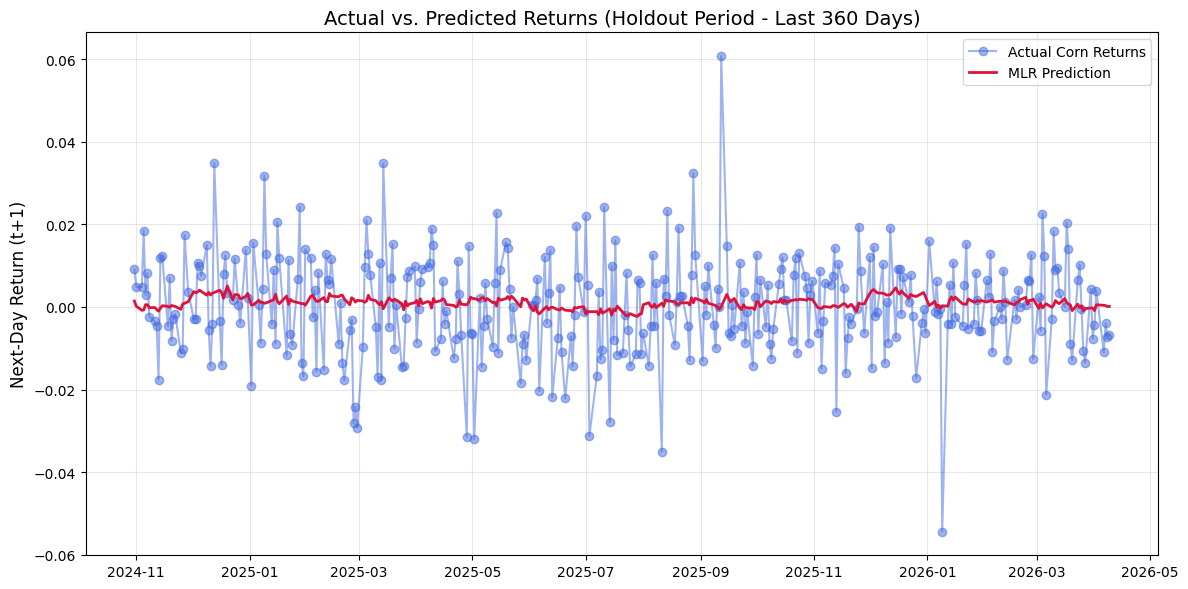

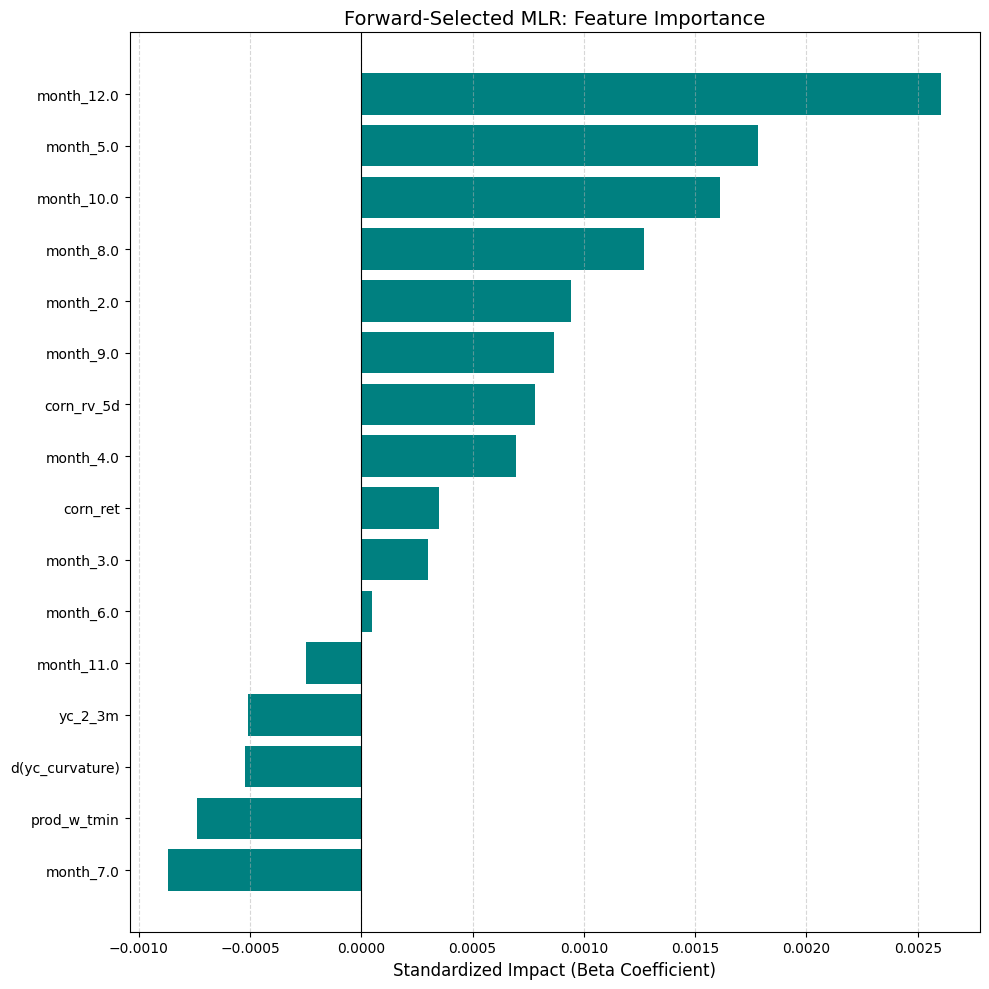

In [57]:
test_preds = forward_selection_model.predict(X_test)
subset_days = 360   # Focus on the most recent 360 trading days to see the fit clearly

plt.figure(figsize=(12, 6))
plt.plot(y_test.index[-subset_days:], y_test.values[-subset_days:], 
         label='Actual Corn Returns', marker='o', alpha=0.5, color='royalblue')
plt.plot(y_test.index[-subset_days:], test_preds[-subset_days:], 
         label='MLR Prediction', linestyle='-', color='crimson', linewidth=2)
plt.title(f'Actual vs. Predicted Returns (Holdout Period - Last {subset_days} Days)', fontsize=14)
plt.ylabel('Next-Day Return (t+1)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 1. Fit the model
forward_selection_model.fit(X_train, y_train)

# 2. Extract Feature Names and Coefficients
# Note the change from 'onehot' to 'ohe' to match the previous code block
ohe = forward_selection_model.named_steps['preprocessor'].named_transformers_['cat'].named_steps['onehot']
feature_names = selected_features + ohe.get_feature_names_out(['month']).tolist()
coeffs = forward_selection_model.named_steps['regressor'].coef_

coef_df = pd.DataFrame({'Feature': feature_names, 'Weight': coeffs}).sort_values(by='Weight')
plt.figure(figsize=(10, 10))
plt.barh(coef_df['Feature'], coef_df['Weight'], color='teal')
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Forward-Selected MLR: Feature Importance', fontsize=14)
plt.xlabel('Standardized Impact (Beta Coefficient)', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Returns increase with increase in yesterday's returns which shows some auto-correlation in corn future returns. Returns increases when short-term yield spread (2yr - 3mo) decreases that means when 3mo yield increases in comparison to 2yr (short-term recessionary risk), corn futures returns increase which makes sense from a risk premium standpoint. When yield curve's curvature increases, corn futures returns decrease which makes sense as well since it can signify decreased recessionary risk for the rest of maturity of the corn future contract compared to the coming years. As avg minimum temperature increases or if the month is July, returns decrease which makes sense since warmer days are true for summer and summer (July) is the harvest season when yields are higher so supply is higher and hence price is lower. December (winter) and May(growing season) are when corn supply is lowest so returns are accordingly higher.

## Lasso, Ridge and Elastic Net Regression

In [66]:
# Lasso
lasso_alphas = np.logspace(-5, -1, 30)
lasso_cv_rmse = []
for alpha in lasso_alphas:
    model = Pipeline([
        ("prep", preprocessor_scaled),
        ("model", Lasso(alpha=alpha, max_iter=20000))
    ])
    lasso_cv_rmse.append(cv_rmse(model, X_train, y_train, tscv))
best_lasso_alpha = lasso_alphas[np.argmin(lasso_cv_rmse)]
print("Best Lasso alpha:", best_lasso_alpha)
best_lasso = Pipeline([
    ("prep", preprocessor_scaled),
    ("model", Lasso(alpha=best_lasso_alpha, max_iter=20000))
])

# Ridge
ridge_alphas = np.logspace(-3, 7, 30)
ridge_cv_rmse = []
for alpha in ridge_alphas:
    model = Pipeline([
        ("prep", preprocessor_scaled),
        ("model", Ridge(alpha=alpha))
    ])
    ridge_cv_rmse.append(cv_rmse(model, X_train, y_train, tscv))
best_ridge_alpha = ridge_alphas[np.argmin(ridge_cv_rmse)]
print("Best Ridge alpha:", best_ridge_alpha)
best_ridge = Pipeline([
    ("prep", preprocessor_scaled),
    ("model", Ridge(alpha=best_ridge_alpha))
])

# Elastic Net
enet_alphas = np.logspace(-5, -1, 20)
enet_l1_ratios = [0.1, 0.3, 0.5, 0.7, 0.9]
enet_results = []
for alpha in enet_alphas:
    for l1_ratio in enet_l1_ratios:
        model = Pipeline([
            ("prep", preprocessor_scaled),
            ("model", ElasticNet(alpha=alpha, l1_ratio=l1_ratio, max_iter=50000))   # higher iterations needed for convergence
        ])
        rmse = cv_rmse(model, X_train, y_train, tscv)
        enet_results.append((alpha, l1_ratio, rmse))
enet_df = pd.DataFrame(enet_results, columns=["alpha", "l1_ratio", "cv_rmse"])
best_row = enet_df.loc[enet_df["cv_rmse"].idxmin()]
best_enet_alpha = best_row["alpha"]
best_enet_l1 = best_row["l1_ratio"]
print("Best Elastic Net alpha:", best_enet_alpha)
print("Best Elastic Net l1_ratio:", best_enet_l1)
best_enet = Pipeline([
    ("prep", preprocessor_scaled),
    ("model", ElasticNet(alpha=best_enet_alpha, l1_ratio=best_enet_l1, max_iter=20000))
])

Best Lasso alpha: 0.0030391953823131978
Best Ridge alpha: 17433.28822199991
Best Elastic Net alpha: 0.003359818286283781
Best Elastic Net l1_ratio: 0.7


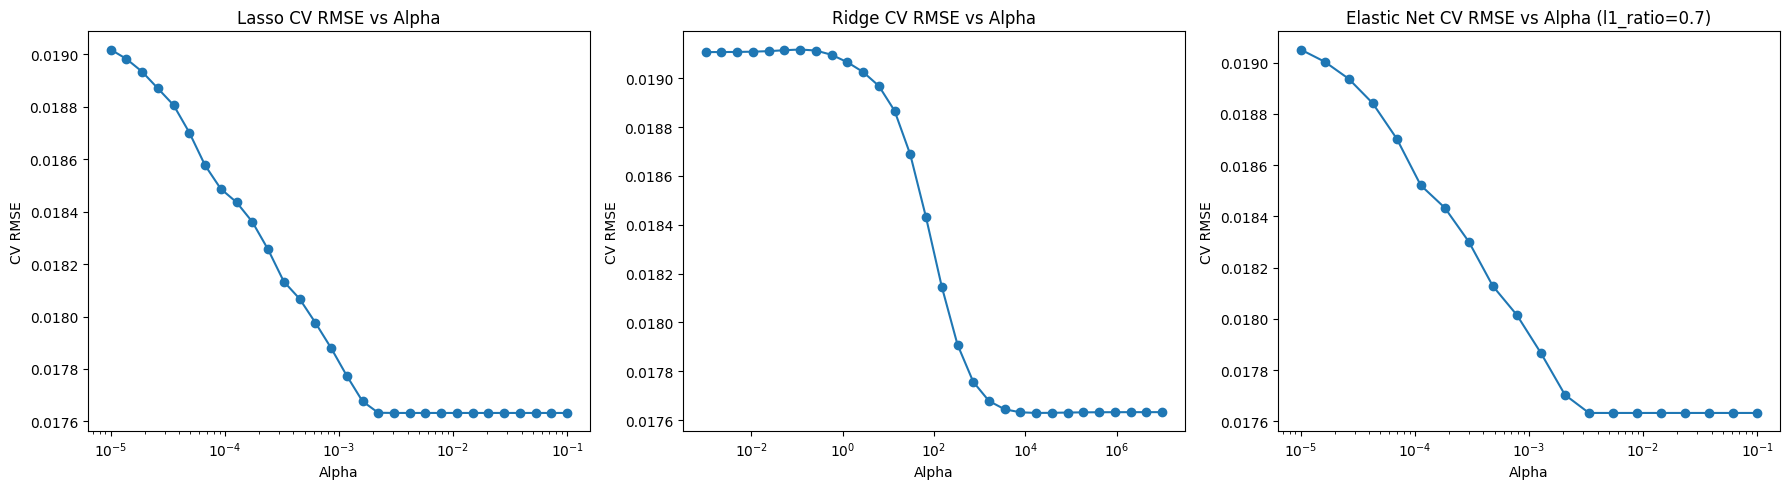

In [67]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(lasso_alphas, lasso_cv_rmse, marker="o")
axes[0].set_xscale("log")
axes[0].set_title("Lasso CV RMSE vs Alpha")
axes[0].set_xlabel("Alpha")
axes[0].set_ylabel("CV RMSE")

axes[1].plot(ridge_alphas, ridge_cv_rmse, marker="o")
axes[1].set_xscale("log")
axes[1].set_title("Ridge CV RMSE vs Alpha")
axes[1].set_xlabel("Alpha")
axes[1].set_ylabel("CV RMSE")

# Plot best ENet RMSE by alpha for the chosen l1_ratio
enet_best_l1_df = enet_df[enet_df["l1_ratio"] == best_enet_l1].sort_values("alpha")
axes[2].plot(enet_best_l1_df["alpha"], enet_best_l1_df["cv_rmse"], marker="o")
axes[2].set_xscale("log")
axes[2].set_title(f"Elastic Net CV RMSE vs Alpha (l1_ratio={best_enet_l1})")
axes[2].set_xlabel("Alpha")
axes[2].set_ylabel("CV RMSE")

plt.tight_layout()
plt.show()

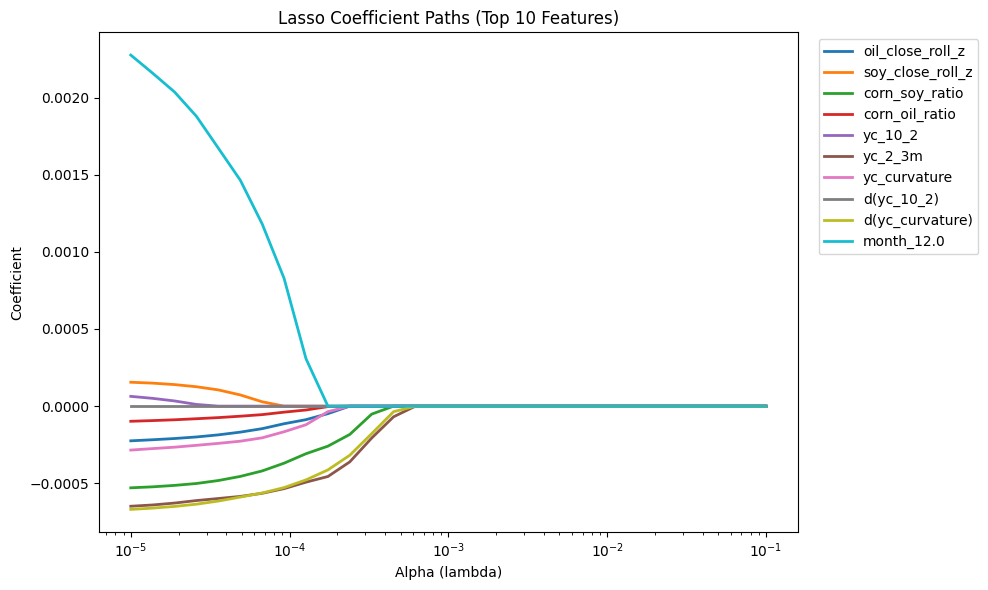

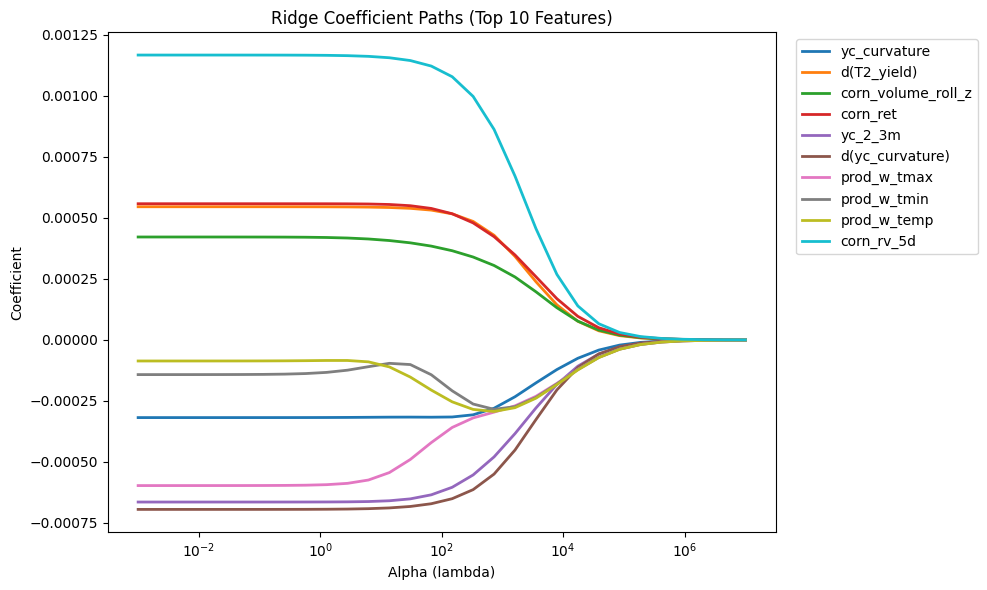

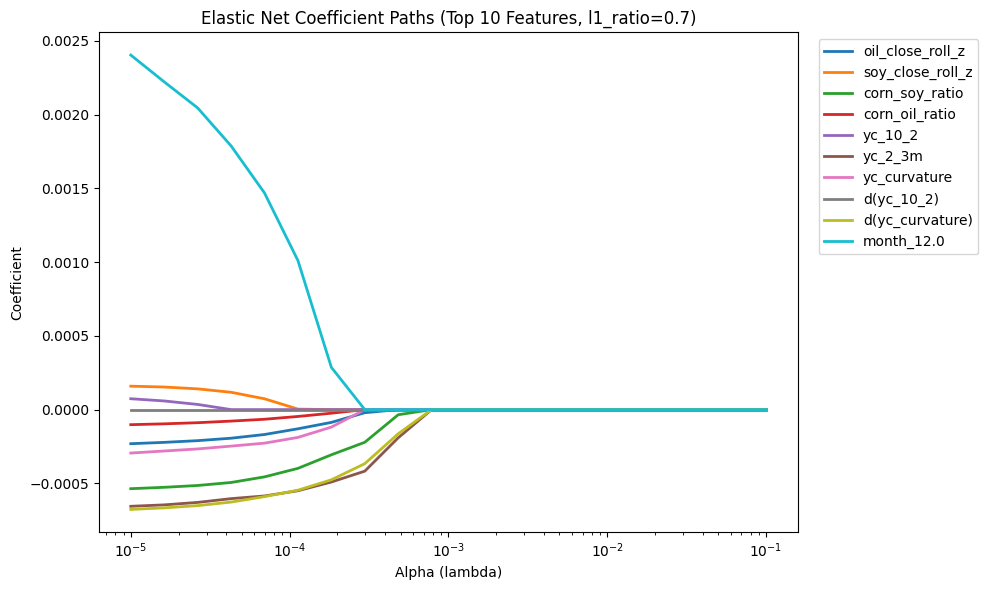

In [68]:
prep_fitted = preprocessor_scaled.fit(X_train)
X_train_proc = prep_fitted.transform(X_train)

# Build post-preprocessing feature names
feature_names_num = numeric_cols
feature_names_cat = prep_fitted.named_transformers_["cat"] \
    .named_steps["onehot"] \
    .get_feature_names_out(categorical_cols)

feature_names = list(feature_names_num) + list(feature_names_cat)

def plot_coef_paths(
    X_proc,
    y,
    model_type="lasso",
    alphas=None,
    l1_ratio=0.7,
    feature_names=None,
    top_n=10,
    title=None
):
    """
    Plot coefficient paths for Lasso / Ridge / Elastic Net.
    Only plots top_n features based on best-model absolute coefficient size.
    """
    if alphas is None:
        raise ValueError("alphas must be provided")

    coef_path = []

    # Fit path
    for alpha in alphas:
        if model_type == "lasso":
            mdl = Lasso(alpha=alpha, max_iter=50000)
        elif model_type == "ridge":
            mdl = Ridge(alpha=alpha)
        elif model_type == "enet":
            mdl = ElasticNet(alpha=alpha, l1_ratio=l1_ratio, max_iter=50000)
        else:
            raise ValueError("model_type must be one of: 'lasso', 'ridge', 'enet'")

        mdl.fit(X_proc, y)
        coef_path.append(mdl.coef_)

    coef_path = np.array(coef_path)

    # Find best alpha model again for labeling top features
    if model_type == "lasso":
        best_model = Lasso(alpha=best_lasso_alpha, max_iter=50000).fit(X_proc, y)
    elif model_type == "ridge":
        best_model = Ridge(alpha=best_ridge_alpha).fit(X_proc, y)
    else:
        best_model = ElasticNet(alpha=best_enet_alpha, l1_ratio=best_enet_l1, max_iter=50000).fit(X_proc, y)

    top_idx = np.argsort(np.abs(best_model.coef_))[-top_n:]

    plt.figure(figsize=(10, 6))
    for j in top_idx:
        label = feature_names[j] if feature_names is not None else f"X{j}"
        plt.plot(alphas, coef_path[:, j], lw=2, label=label)

    plt.xscale("log")
    plt.xlabel("Alpha (lambda)")
    plt.ylabel("Coefficient")
    plt.title(title if title else f"{model_type.title()} Coefficient Paths")
    plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

plot_coef_paths(
    X_train_proc, y_train,
    model_type="lasso",
    alphas=lasso_alphas,
    feature_names=feature_names,
    top_n=10,
    title="Lasso Coefficient Paths (Top 10 Features)"
)

plot_coef_paths(
    X_train_proc, y_train,
    model_type="ridge",
    alphas=ridge_alphas,
    feature_names=feature_names,
    top_n=10,
    title="Ridge Coefficient Paths (Top 10 Features)"
)

plot_coef_paths(
    X_train_proc, y_train,
    model_type="enet",
    alphas=enet_alphas,
    l1_ratio=best_enet_l1,
    feature_names=feature_names,
    top_n=10,
    title=f"Elastic Net Coefficient Paths (Top 10 Features, l1_ratio={best_enet_l1})"
)

## Regression Trees and Random Forest

Best Tree depth: 1
Best Tree min_samples_leaf: 5
Best Tree CV RMSE: 0.017648625448855017


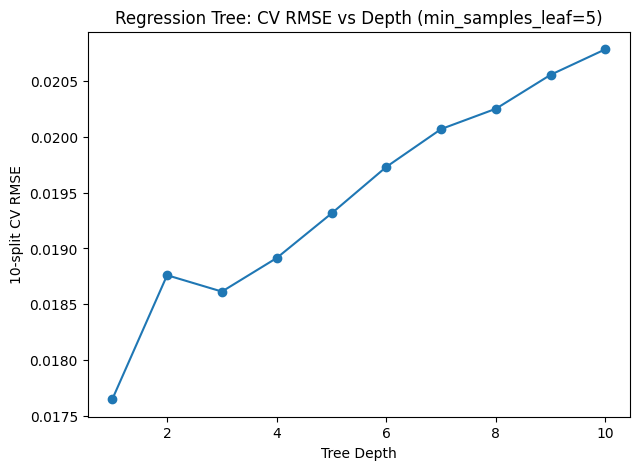

In [69]:
tree_results = []
for depth in range(1, 11):
    for leaf in [5, 10, 20, 40]:
        model = Pipeline([
            ("prep", preprocessor_noscale),
            ("model", DecisionTreeRegressor(
                max_depth=depth,
                min_samples_leaf=leaf,
                random_state=1
            ))
        ])
        rmse = cv_rmse(model, X_train, y_train, tscv)
        tree_results.append((depth, leaf, rmse))
tree_df = pd.DataFrame(tree_results, columns=["max_depth", "min_samples_leaf", "cv_rmse"])
best_tree_row = tree_df.loc[tree_df["cv_rmse"].idxmin()]
best_tree_depth = int(best_tree_row["max_depth"])
best_tree_leaf = int(best_tree_row["min_samples_leaf"])
best_tree = Pipeline([
    ("prep", preprocessor_noscale),
    ("model", DecisionTreeRegressor(
        max_depth=best_tree_depth,
        min_samples_leaf=best_tree_leaf,
        random_state=1
    ))
])
print("Best Tree depth:", best_tree_depth)
print("Best Tree min_samples_leaf:", best_tree_leaf)
print("Best Tree CV RMSE:", best_tree_row["cv_rmse"])

plot_df = tree_df[tree_df["min_samples_leaf"] == best_tree_leaf].sort_values("max_depth")
plt.figure(figsize=(7,5))
plt.plot(plot_df["max_depth"], plot_df["cv_rmse"], marker="o")
plt.xlabel("Tree Depth")
plt.ylabel("10-split CV RMSE")
plt.title(f"Regression Tree: CV RMSE vs Depth (min_samples_leaf={best_tree_leaf})")
plt.show()

Best RF n_trees: 50
Best RF max_depth: 1
Best RF min_samples_leaf: 5
Best RF CV RMSE: 0.01763782032046434


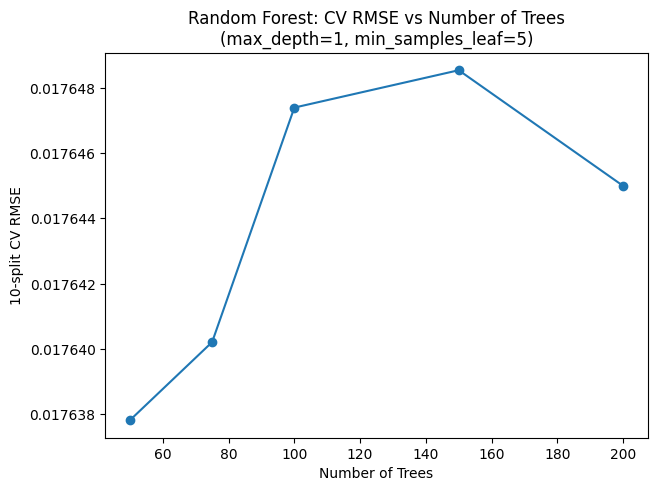

In [70]:
rf_results = []

for n_trees in [50, 75, 100, 150, 200]:
    for depth in [1, 3, 5, 7, None]:
        for leaf in [5, 10, 20]:
            model = Pipeline([
                ("prep", preprocessor_noscale),
                ("model", RandomForestRegressor(
                    n_estimators=n_trees,
                    max_depth=depth,
                    min_samples_leaf=leaf,
                    max_features="sqrt",   # good default
                    random_state=1,
                    n_jobs=-1
                ))
            ])
            rmse = cv_rmse(model, X_train, y_train, tscv)
            rf_results.append((n_trees, depth, leaf, rmse))
rf_df = pd.DataFrame(rf_results, columns=["n_trees", "max_depth", "min_samples_leaf", "cv_rmse"])
best_rf_row = rf_df.loc[rf_df["cv_rmse"].idxmin()]
best_rf_n = int(best_rf_row["n_trees"])
best_rf_depth = int(None if pd.isna(best_rf_row["max_depth"]) else best_rf_row["max_depth"])
best_rf_leaf = int(best_rf_row["min_samples_leaf"])
best_rf = Pipeline([
    ("prep", preprocessor_noscale),
    ("model", RandomForestRegressor(
        n_estimators=best_rf_n,
        max_depth=best_rf_depth,
        min_samples_leaf=best_rf_leaf,
        max_features="sqrt",
        random_state=1,
        n_jobs=-1
    ))
])
print("Best RF n_trees:", best_rf_n)
print("Best RF max_depth:", best_rf_depth)
print("Best RF min_samples_leaf:", best_rf_leaf)
print("Best RF CV RMSE:", best_rf_row["cv_rmse"])

plot_rf = rf_df[
    (rf_df["max_depth"].astype(str) == str(float(best_rf_depth))) &
    (rf_df["min_samples_leaf"] == best_rf_leaf)
].sort_values("n_trees")
plt.figure(figsize=(7,5))
plt.plot(plot_rf["n_trees"], plot_rf["cv_rmse"], marker="o")
plt.xlabel("Number of Trees")
plt.ylabel("10-split CV RMSE")
plt.title(f"Random Forest: CV RMSE vs Number of Trees\n(max_depth={best_rf_depth}, min_samples_leaf={best_rf_leaf})")
plt.show()

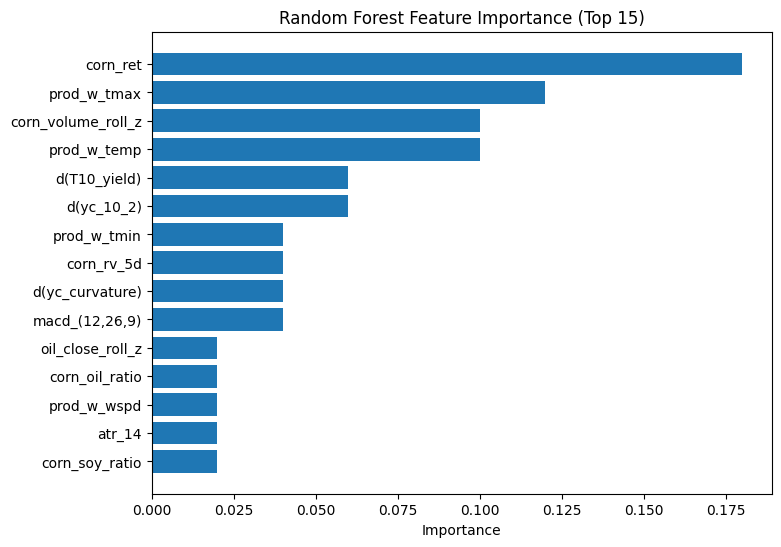

In [71]:
best_rf.fit(X_train, y_train)
prep = best_rf.named_steps["prep"]
rf_model = best_rf.named_steps["model"]
feature_names_num = numeric_cols
feature_names_cat = prep.named_transformers_["cat"] \
    .named_steps["onehot"] \
    .get_feature_names_out(categorical_cols)
feature_names = list(feature_names_num) + list(feature_names_cat)
rf_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": rf_model.feature_importances_
}).sort_values("importance", ascending=False)
top_rf = rf_importance.head(15).sort_values("importance")

plt.figure(figsize=(8,6))
plt.barh(top_rf["feature"], top_rf["importance"])
plt.xlabel("Importance")
plt.title("Random Forest Feature Importance (Top 15)")
plt.show()

## Boosting

In [58]:
xgb_results = []
for n_estimators in [50, 100, 300]:
    for max_depth in [1, 2, 3]:
        for learning_rate in [0.01, 0.05, 0.1]:
            for subsample in [0.5, 0.8, 1.0]:
                model = Pipeline([
                    ("prep", preprocessor_noscale),
                    ("model", XGBRegressor(
                        n_estimators=n_estimators,
                        max_depth=max_depth,
                        learning_rate=learning_rate,
                        subsample=subsample,
                        colsample_bytree=0.8,
                        reg_lambda=1.0,
                        random_state=42,
                        n_jobs=-1,
                        objective="reg:squarederror"
                    ))
                ])

                rmse = cv_rmse(model, X_train, y_train, tscv)
                xgb_results.append((n_estimators, max_depth, learning_rate, subsample, rmse))

xgb_df = pd.DataFrame(
    xgb_results,
    columns=["n_estimators", "max_depth", "learning_rate", "subsample", "cv_rmse"]
)

best_xgb_row = xgb_df.loc[xgb_df["cv_rmse"].idxmin()]
best_xgb = Pipeline([
    ("prep", preprocessor_noscale),
    ("model", XGBRegressor(
        n_estimators=int(best_xgb_row["n_estimators"]),
        max_depth=int(best_xgb_row["max_depth"]),
        learning_rate=float(best_xgb_row["learning_rate"]),
        subsample=float(best_xgb_row["subsample"]),
        colsample_bytree=0.8,
        reg_lambda=1.0,
        random_state=1,
        n_jobs=-1,
        objective="reg:squarederror"
    ))
])

print("Best XGBoosting Regressor:")
print(best_xgb_row)
xgb_res = evaluate_holdout("XGBoost Regression", best_xgb, X_train, y_train, X_test, y_test)
print(xgb_res)

Best XGBoosting Regressor:
n_estimators     50.000000
max_depth         1.000000
learning_rate     0.010000
subsample         1.000000
cv_rmse           0.017623
Name: 2, dtype: float64
{'model': 'XGBoost Regression', 'test_rmse': np.float64(0.01763123239413991), 'test_mae': 0.012130434845212179, 'test_r2': -0.0007986286331593817}


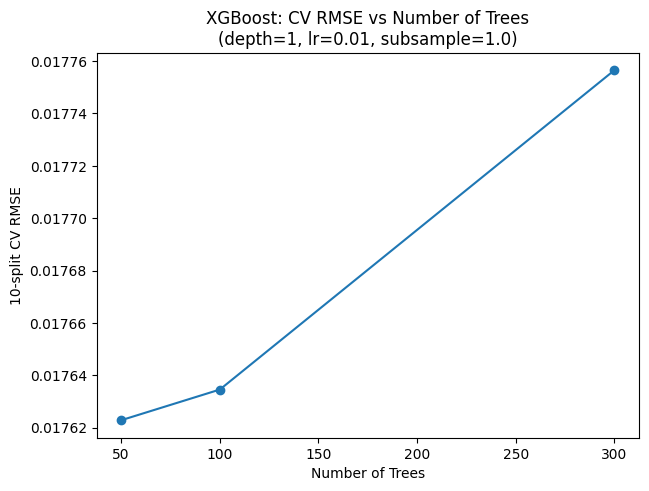

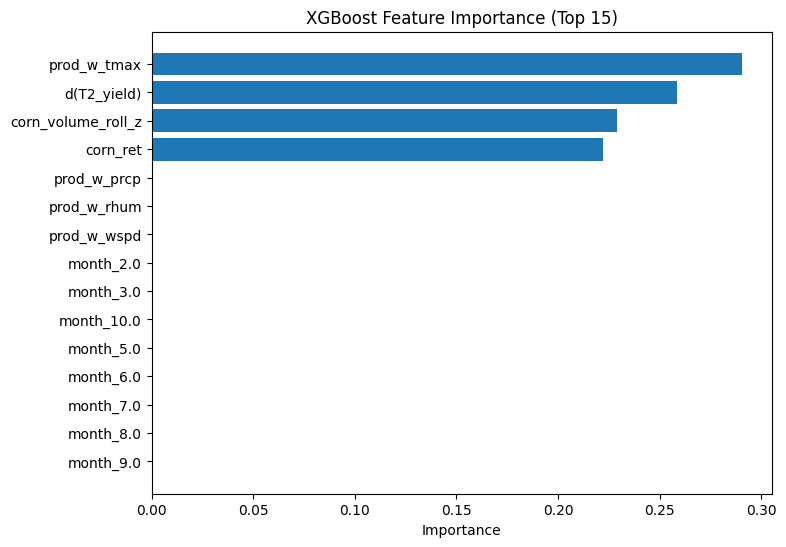

In [59]:
plot_xgb = xgb_df[
    (xgb_df["max_depth"] == best_xgb_row["max_depth"]) &
    (xgb_df["learning_rate"] == best_xgb_row["learning_rate"]) &
    (xgb_df["subsample"] == best_xgb_row["subsample"])
].sort_values("n_estimators")

best_xgb.fit(X_train, y_train)
prep = best_xgb.named_steps["prep"]
xgb_model = best_xgb.named_steps["model"]
feature_names_num = numeric_cols
feature_names_cat = prep.named_transformers_["cat"] \
    .named_steps["onehot"] \
    .get_feature_names_out(categorical_cols)
feature_names = list(feature_names_num) + list(feature_names_cat)
xgb_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": xgb_model.feature_importances_
}).sort_values("importance", ascending=False)

plt.figure(figsize=(7,5))
plt.plot(plot_xgb["n_estimators"], plot_xgb["cv_rmse"], marker="o")
plt.xlabel("Number of Trees")
plt.ylabel("10-split CV RMSE")
plt.title(
    f"XGBoost: CV RMSE vs Number of Trees\n"
    f"(depth={int(best_xgb_row['max_depth'])}, "
    f"lr={best_xgb_row['learning_rate']}, "
    f"subsample={best_xgb_row['subsample']})"
)

top_xgb = xgb_importance.head(15).sort_values("importance")

plt.figure(figsize=(8,6))
plt.barh(top_xgb["feature"], top_xgb["importance"])
plt.xlabel("Importance")
plt.title("XGBoost Feature Importance (Top 15)")
plt.show()

## Support Vector Machines

In [63]:
linear_svr_results = []

for C in [0.1, 1]:
    for epsilon in [0.0005, 0.001]:
        model = Pipeline([
            ("prep", preprocessor_scaled),
            ("model", SVR(kernel="linear", C=C, epsilon=epsilon))
        ])
        rmse = cv_rmse(model, X_train, y_train, tscv)
        linear_svr_results.append((C, epsilon, rmse))

linear_svr_df = pd.DataFrame(linear_svr_results, columns=["C", "epsilon", "cv_rmse"])
best_linear_svr_row = linear_svr_df.loc[linear_svr_df["cv_rmse"].idxmin()]
print("Best Linear SVR:")
print(best_linear_svr_row)

best_linear_svr = Pipeline([
    ("prep", preprocessor_scaled),
    ("model", SVR(
        kernel="linear",
        C=float(best_linear_svr_row["C"]),
        epsilon=float(best_linear_svr_row["epsilon"])
    ))
])
linear_svr_res = evaluate_holdout(
    "Linear SVR",
    best_linear_svr,
    X_train,
    y_train,
    X_test,
    y_test
)
linear_svr_res

Best Linear SVR:
C          0.100000
epsilon    0.000500
cv_rmse    0.018759
Name: 0, dtype: float64


{'model': 'Linear SVR',
 'test_rmse': np.float64(0.01766482728665212),
 'test_mae': 0.012185895735473962,
 'test_r2': -0.004616144430608982}

In [64]:
rbf_svr_results = []
for C in [0.1, 1, 10]:
    for epsilon in [0.0005, 0.001]:
        for gamma in ["scale", 0.05, 0.1, 0.5]:
            model = Pipeline([
                ("prep", preprocessor_scaled),
                ("model", SVR(kernel="rbf", C=C, epsilon=epsilon, gamma=gamma))
            ])
            rmse = cv_rmse(model, X_train, y_train, tscv)
            rbf_svr_results.append((C, epsilon, gamma, rmse))
rbf_svr_df = pd.DataFrame(rbf_svr_results, columns=["C", "epsilon", "gamma", "cv_rmse"])
best_rbf_svr_row = rbf_svr_df.loc[rbf_svr_df["cv_rmse"].idxmin()]
print("Best Radial SVR:")
print(best_rbf_svr_row)

best_rbf_svr = Pipeline([
    ("prep", preprocessor_scaled),
    ("model", SVR(
        kernel="rbf",
        C=float(best_rbf_svr_row["C"]),
        epsilon=float(best_rbf_svr_row["epsilon"]),
        gamma=best_rbf_svr_row["gamma"]
    ))
])
rbf_svr_res = evaluate_holdout(
    "Radial SVR",
    best_rbf_svr,
    X_train,
    y_train,
    X_test,
    y_test
)
rbf_svr_res

Best Radial SVR:
C               0.1
epsilon      0.0005
gamma           0.5
cv_rmse    0.017632
Name: 3, dtype: object


{'model': 'Radial SVR',
 'test_rmse': np.float64(0.01763642211258069),
 'test_mae': 0.012103698145124636,
 'test_r2': -0.001387881543457592}

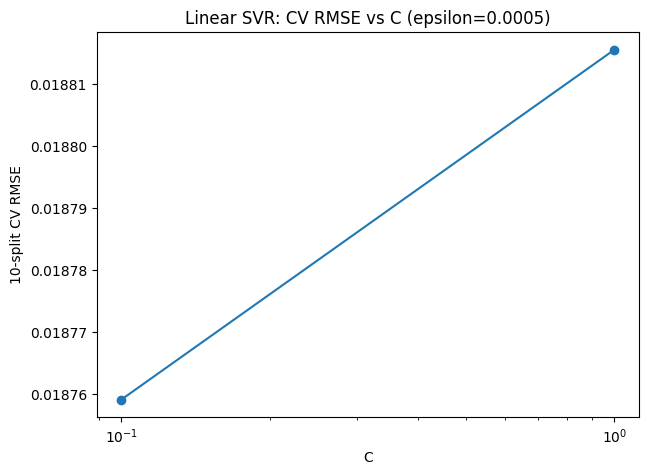

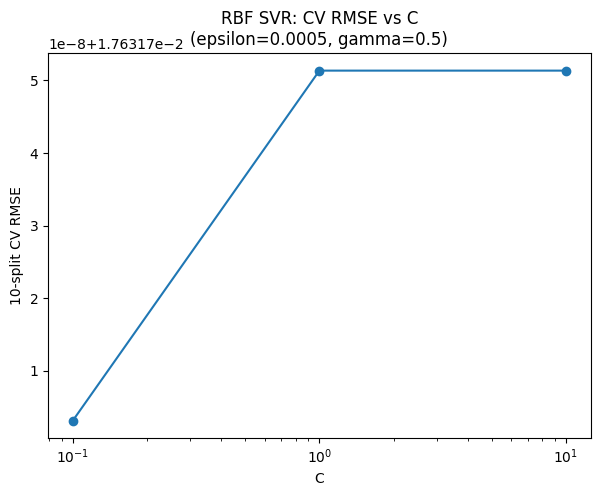

In [65]:
plot_linear_svr = linear_svr_df[
    linear_svr_df["epsilon"] == best_linear_svr_row["epsilon"]
].sort_values("C")

plt.figure(figsize=(7,5))
plt.plot(plot_linear_svr["C"], plot_linear_svr["cv_rmse"], marker="o")
plt.xscale("log")
plt.xlabel("C")
plt.ylabel("10-split CV RMSE")
plt.title(f"Linear SVR: CV RMSE vs C (epsilon={best_linear_svr_row['epsilon']})")
plt.show()

plot_rbf_svr = rbf_svr_df[
    (rbf_svr_df["epsilon"] == best_rbf_svr_row["epsilon"]) &
    (rbf_svr_df["gamma"] == best_rbf_svr_row["gamma"])
].sort_values("C")

plt.figure(figsize=(7,5))
plt.plot(plot_rbf_svr["C"], plot_rbf_svr["cv_rmse"], marker="o")
plt.xscale("log")
plt.xlabel("C")
plt.ylabel("10-split CV RMSE")
plt.title(
    f"RBF SVR: CV RMSE vs C\n"
    f"(epsilon={best_rbf_svr_row['epsilon']}, gamma={best_rbf_svr_row['gamma']})"
)
plt.show()

## K-Nearest Neighbours

In [60]:
k_grid = [1, 3, 5, 7, 9, 15, 21, 31, 41, 61, 91, 200, 300]
knn_cv_rmse = []

for k in k_grid:
    model = Pipeline([
        ("prep", preprocessor_scaled),
        ("model", KNeighborsRegressor(n_neighbors=k))
    ])
    rmse = cv_rmse(model, X_train, y_train, tscv)
    knn_cv_rmse.append(rmse)

best_k = k_grid[np.argmin(knn_cv_rmse)]
best_knn = Pipeline([
    ("prep", preprocessor_scaled),
    ("model", KNeighborsRegressor(n_neighbors=best_k))
])
best_knn.fit(X_train, y_train)
print("Best K:", best_k)
print("Best CV RMSE:", min(knn_cv_rmse))

Best K: 300
Best CV RMSE: 0.01762251463294536


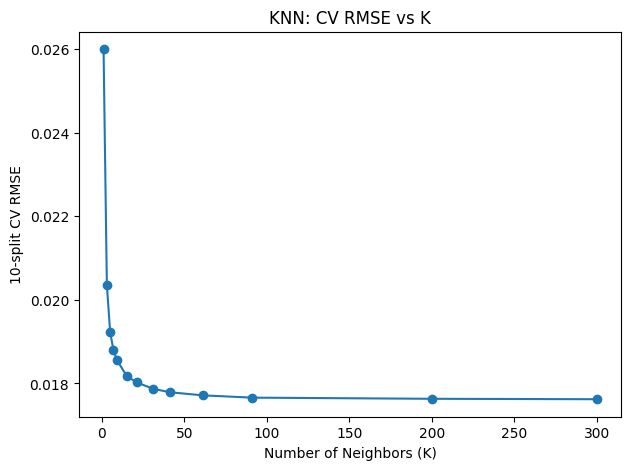

In [61]:
plt.figure(figsize=(7,5))
plt.plot(k_grid, knn_cv_rmse, marker="o")
plt.xlabel("Number of Neighbors (K)")
plt.ylabel("10-split CV RMSE")
plt.title("KNN: CV RMSE vs K")
plt.show()

## Holdout Sample Results

In [74]:
lasso_res = evaluate_holdout("Lasso Regression", best_lasso, X_train, y_train, X_test, y_test)
ridge_res = evaluate_holdout("Ridge Regression", best_ridge, X_train, y_train, X_test, y_test)
enet_res = evaluate_holdout("Elastic Net Regression", best_enet, X_train, y_train, X_test, y_test)
tree_res = evaluate_holdout("Regression Tree", best_tree, X_train, y_train, X_test, y_test)
rf_res = evaluate_holdout("Random Forest", best_rf, X_train, y_train, X_test, y_test)
knn_res = evaluate_holdout("KNN Regression", best_knn,  X_train, y_train, X_test, y_test)
results = pd.DataFrame([mlr_model_with_mc_res, mlr_model_wo_mc_res, forward_selection_res, lasso_res, ridge_res, enet_res, tree_res, rf_res, xgb_res, linear_svr_res, rbf_svr_res, knn_res]).sort_values("test_rmse")
results

,model,test_rmse,test_mae,test_r2
11,KNN Regression,0.017579,0.012115,0.005106
7,Random Forest,0.017619,0.012111,0.000567
3,Lasso Regression,0.017628,0.012097,-0.000480
5,Elastic Net Regression,0.017628,0.012097,-0.000480
4,Ridge Regression,0.017630,0.012123,-0.000649
8,XGBoost Regression,0.017631,0.012130,-0.000799
10,Radial SVR,0.017636,0.012104,-0.001388
6,Regression Tree,0.017647,0.012177,-0.002641
9,Linear SVR,0.017665,0.012186,-0.004616
2,Forward-selected MLR model,0.017678,0.012238,-0.006103


### What our results are saying:
1) Everything is clustered insanely tight  
    - RMSE range: 0.017579 → 0.017759  
    - That’s basically identical performance across all models.

2) Negative R^2 everywhere (except barely KNN/RF)  
	- Most models: negative R^2
	- KNN / RF: barely positive (~0.0005)
    - Meaning we are mostly losing compared to predicting just the mean. This is expected from any mildly efficient financial market.

3) Why KNN and RF slightly win
    - Because they smooth noise locally (KNN) or average noisy splits (RF)
    - So they reduce variance just enough to beat the mean by a microscopic amount which is not true signal.

4) MLR with multi-collinearity reduction and forward-selection
    - Show improvement compared to baseline MLR but not enough compared to non-linear models showing existence of non-linear relationships in the data.

### Summary:
Across a wide range of models — including linear regression, regularized methods, tree-based models, boosting, k-nearest neighbors, and support vector regression — out-of-sample performance remains tightly clustered and close to a mean-prediction baseline. This suggests that short-horizon corn returns exhibit a low signal-to-noise ratio, and that neither linear nor nonlinear models are able to extract stable predictive structure from the available features.

### Future Improvements:
- Change the target to more mid-term returns like 5-day or 10-day returns to increase signal-to-noise ratio
- Change to a classification problem (predict +ve or -ve returns)
- Regime-based modeling by setting up splines wherever there is a volatility or macro regime change
- Dimensionality reduction using PCA on macro and weather data
